In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Use small subset to avoid crashing
x_train=x_train[:5000]
y_train=y_train[:5000]

x_test=x_test[:1000]
y_test=y_test[:1000]

# Resize for MobileNet
x_train=tf.image.resize(x_train,(96,96))/255.0
x_test=tf.image.resize(x_test,(96,96))/255.0

In [3]:
base_model=MobileNetV2(
weights='imagenet',
include_top=False,
input_shape=(96,96,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
base_model.trainable=False

In [5]:
model=models.Sequential([
base_model,
layers.GlobalAveragePooling2D(),
layers.Dense(128,activation='relu'),
layers.Dense(10,activation='softmax')
])

In [6]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [7]:
history1=model.fit(
x_train,y_train,
epochs=3,
validation_data=(x_test,y_test)
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 239ms/step - accuracy: 0.6466 - loss: 1.0321 - val_accuracy: 0.7280 - val_loss: 0.8040
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 250ms/step - accuracy: 0.7756 - loss: 0.6314 - val_accuracy: 0.7520 - val_loss: 0.7447
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy: 0.8334 - loss: 0.4807 - val_accuracy: 0.7520 - val_loss: 0.7201


In [8]:
base_model.trainable=True

for layer in base_model.layers[:-20]:
    layer.trainable=False

model.compile(
optimizer=tf.keras.optimizers.Adam(1e-5),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

history2=model.fit(
x_train,y_train,
epochs=3,
validation_data=(x_test,y_test)
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 333ms/step - accuracy: 0.6772 - loss: 0.9731 - val_accuracy: 0.7420 - val_loss: 0.8063
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 321ms/step - accuracy: 0.7666 - loss: 0.6753 - val_accuracy: 0.7510 - val_loss: 0.8088
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 349ms/step - accuracy: 0.8026 - loss: 0.5836 - val_accuracy: 0.7650 - val_loss: 0.7777


In [9]:
loss1,acc1=model.evaluate(x_test,y_test)
print("Accuracy:",acc1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.7650 - loss: 0.7777
Accuracy: 0.7649999856948853


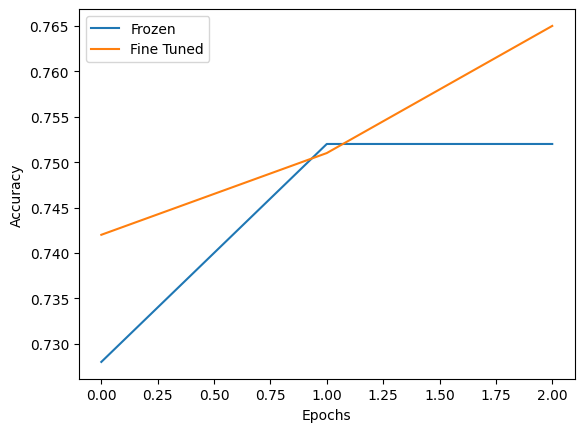

In [10]:
plt.plot(history1.history['val_accuracy'],
label='Frozen')

plt.plot(history2.history['val_accuracy'],
label='Fine Tuned')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()